In [51]:
from datasets import load_dataset
from tqdm import tqdm
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from collections import Counter
import datetime
from matplotlib.ticker import StrMethodFormatter

In [4]:
ds = load_dataset('chcaa/eno-embs-old-news', split="train")

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/61 [00:00<?, ?it/s]

In [18]:
# -------------------------------------------------------------------
# Extract dates (as a simple list)
# -------------------------------------------------------------------
# ⚡ This loads only the 'date' column, not the entire dataset
dates = ds["date"]

# -------------------------------------------------------------------
# Count frequencies per date
# -------------------------------------------------------------------
# (If dates are daily ISO strings like '1793-06-01')
freq = Counter(dates)

# Convert to a small dataframe for plotting
freq_df = pd.DataFrame(freq.items(), columns=["date", "count"])

In [19]:
# Convert safely with datetime
freq_df["date"] = freq_df["date"].apply(lambda x: datetime.date.fromisoformat(x))

In [20]:
freq_df["year"] = freq_df["date"].apply(lambda d: d.year)
year_counts = freq_df.groupby("year")["count"].sum().reset_index()

In [31]:
# freq_df already has columns: ['date', 'count']
# Extract 'YYYY-MM' from the date string
freq_df["month"] = freq_df["date"].astype(str).str[:7]

# Group and sort
month_counts = (
    freq_df.groupby("month")["count"]
    .sum()
    .reset_index()
    .sort_values("month")
)

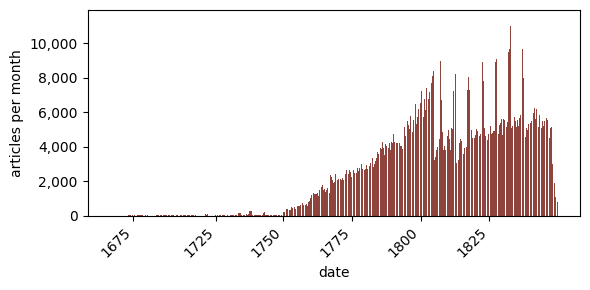

In [59]:
# Sort by chronological order (as strings still works for YYYY-MM)
month_counts = month_counts.sort_values("month")

# Extract years from "YYYY-MM"
month_counts["year"] = month_counts["month"].str[:4].astype(int)

# Find the months that are January AND every 10th year
tick_mask = (month_counts["month"].str.endswith("-01")) & (month_counts["year"] % 25 == 0)
tick_positions = month_counts.loc[tick_mask, "month"]
tick_labels = month_counts.loc[tick_mask, "year"].astype(str)

# -------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------
plt.figure(figsize=(6, 3))
plt.bar(month_counts["month"], month_counts["count"], color="#8E443D")

plt.gca().yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

plt.xlabel("date")
plt.ylabel("articles per month")

# ✅ Add tick marks every 10 years (January)
plt.xticks(tick_positions, tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../figs/plot_months.pdf", bbox_inches="tight")
plt.show()

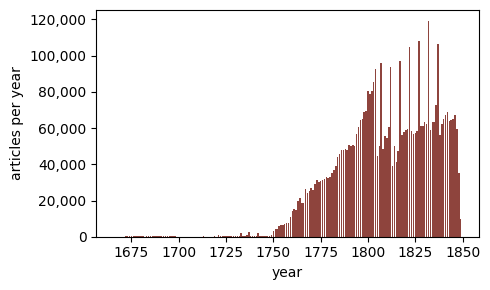

In [62]:
plt.figure(figsize=(5, 3))
plt.bar(year_counts["year"], year_counts["count"], color="#8E443D")

plt.gca().yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
#plt.title("Number of articles per year")
plt.xlabel("year")
plt.ylabel("articles per year")
#plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figs/plot_years.pdf', bbox_inches='tight')
plt.show()

In [63]:
palette = ['#8E443D', '#CB9173', '#004E64', '#9BBEC7']